# Studying SCENIC+ TF-peak links

The SCENIC+ results themselves come from: code/multiome_atlas/SCENICplus_sc/

In [1]:
here::i_am("revisions/05_SCENICplus/TF2peak_links.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))
suppressPackageStartupMessages(library(ArchR))


BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

set.seed(1234)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”

                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | 

In [2]:
args = list()

# Metadata
args$GRN = file.path(io$basedir, 'results/multiome_atlas/SCENICplus_sc/scenicplus/eRegulon_metadata_filtered.csv')

# Markers dir
args$markers = file.path(io$basedir, 'results/rna_atac/celltype_markers/')

# outdir
args$outdir = file.path(io$basedir, 'results/revisions/05_SCENICplus/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [3]:
markersPeaks = readRDS(sprintf('%s/markers_Peaks.rds', args$markers))

In [4]:
io$multiome = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/multiome_atlas/'
cisbp_silico_chip = readRDS(file.path(io$multiome, 'vitro_peaks_silicoChIP_cisbp.rds'))
assay(cisbp_silico_chip, 'matches') = assay(cisbp_silico_chip, 'VirtualChipScores') > 0.20
assay(cisbp_silico_chip, 'motifScores') = NULL
assay(cisbp_silico_chip, 'motifMatches') = NULL
assay(cisbp_silico_chip, 'motifCounts') = NULL
assay(cisbp_silico_chip, 'VirtualChipScores') = NULL
# Keep only motifs with more than 40 peaks 
tmp = colSums(assay(cisbp_silico_chip, 'matches') )
keep = names(tmp[tmp > 40])
cisbp_silico_chip = cisbp_silico_chip[,keep]

In [5]:
assay(cisbp_silico_chip)[1:5, 1:5]

5 x 5 sparse Matrix of class "lgCMatrix"
                     AHCTF1 AHRR ALX1 ALX3 ALX4
chr1:3003470-3004070      .    .    .    .    .
chr1:3035598-3036198      :    .    .    .    .
chr1:3062639-3063239      .    .    .    .    .
chr1:3191587-3192187      :    .    :    :    :
chr1:3263590-3264190      .    .    .    .    .

In [6]:
GRN = fread(args$GRN)

In [33]:
GRN[TF == 'Tbx4'][order(-TF2G_rho)] %>% .$Gene %>% unique()

[1] "Tbx4"      "Slc38a4"   "Ngfr"      "Tbx3"      "Wnt5a"     "Tmem119"  
 [7] "Notch2"    "Prdm6"     "Rgs5"      "Ppic"      "Tbx2"      "Igsf3"    
[13] "Coro2a"    "Unc5b"     "Igf2"      "Daam2"     "Phc2"      "Gpc1"     
[19] "Hoxb6"     "Frmpd2"    "Pard3"     "Myrf"      "Twist1"    "Pdgfrb"   
[25] "Slf2"      "Isl1"      "Rnf217"    "Tnfrsf11a" "Cacna2d1"  "Vcan"     
[31] "Pdgfa"     "Ube2h"     "Has2"      "Hdac8"     "Magi3"     "Rhou"     
[37] "Wnt5b"     "Jak1"      "Dsc2"      "Prickle1"  "Hoxd8"     "Klf12"    
[43] "Tns1"      "Adam19"    "Col1a2"    "Cables2"   "Pom121"    "Pkd1"     
[49] "Dennd2a"   "Zfp512"    "Snai1"     "Gse1"      "Igdcc3"    "Tgfb2"    
[55] "Pik3ca"    "Arid5b"    "Gas1"      "Rarg"      "Cep112"    "Ntf3"     
[61] "Hbegf"     "Lpgat1"    "Foxf2"     "Ptges"     "Arhgap45"  "Lnpk"     
[67] "Gbx1"      "Alx3"      "Lgals3bp"  "Adamtsl2"  "Auts2"     "Cyth1"    
[73] "Negr1"     "Nt5e"      "Pdzd2"     "Sall3"     "Mical1"    "Hoxb5"    
[79] "St3gal4"   "Bace2"     "Abcb6"     "Ebf4"      "Iqcb1"     "Dlx3"     
[85] "Sirpa"     "Megf8"     "Arhgef25"  "Slc23a2"   "Celf4"     "Sh2b3"    
[91] "Anpep"     "Sfrp1"     "Hddc2"     "Acsl6"     "Sema3f"

In [9]:
## Make similar format matches from the SCENIC+ GRN
# This is not the most efficient way to do this but it's fast enough
GRN_matrix = mclapply(unique(GRN$TF), function(x){
    tmp = data.table(peak = rownames(cisbp_silico_chip),
                     TF = x) %>%
        .[, bound := ifelse(peak %in% GRN[TF == x, Region], 1, 0)] 
}, mc.cores = 40) %>% rbindlist() %>% # make longlist
    dcast(., peak ~ TF, value.var = 'bound') %>% # convert to wide
    as.data.frame() %>% # as data frame
    tibble::column_to_rownames('peak') %>% # set rownames
    as.matrix() %>% as('lgCMatrix') # convert to sparse matrix

Warning message:
“as(<matrix>, "lgCMatrix") is deprecated since Matrix 1.5-0; do as(as(as(., "lMatrix"), "generalMatrix"), "CsparseMatrix") instead”


In [10]:
GRN_matrix[1:5, 1:5]

5 x 5 sparse Matrix of class "lgCMatrix"
                          Acaa1a Aff4 Ahctf1 Ahdc1 Ahr
chr10:100013997-100014597      .    .      .     .   .
chr10:100015465-100016065      .    .      .     .   .
chr10:100016252-100016852      .    .      .     .   .
chr10:100017131-100017731      .    .      .     .   .
chr10:100018396-100018996      .    .      .     .   .

In [11]:
cisbp_silico_chip

class: RangedSummarizedExperiment 
dim: 234908 534 
metadata(0):
assays(1): matches
rownames(234908): chr1:3003470-3004070 chr1:3035598-3036198 ...
  chrX:169925416-169926016 chrX:169937236-169937836
rowData names(13): score replicateScoreQuantile ... idx N
colnames(534): AHCTF1 AHRR ... ZSCAN10 ZSCAN20
colData names(1): name

In [12]:
GRN_matches = SummarizedExperiment(assays = c('matches' = GRN_matrix)) # create summarized experiment
GRN_matches = as(GRN_matches, 'RangedSummarizedExperiment')
GRN_matches = GRN_matches[rownames(cisbp_silico_chip)] # order rows as before
rowRanges(GRN_matches) = rowRanges(cisbp_silico_chip) # add rowdata --> not sure if necessary?

In [13]:
ArchRProject <- loadArchRProject(io$archR.directory)

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [14]:
# Motif enrichment using SCENIC+ bound peaks
enrichMotifs <- suppressMessages(peakAnnoEnrichment(
    seMarker = markersPeaks,
    ArchRProj = ArchRProject,
    #peakAnnotation = "silicoChIP_CISBP",
    matches = GRN_matches,
    cutOff = "FDR <= 0.1 & Log2FC >= 0.5"
  ))

In [15]:
enrichMotifs

class: SummarizedExperiment 
dim: 570 12 
metadata(0):
assays(10): mlog10Padj mlog10p ... CompareFrequency feature
rownames(570): Acaa1a Aff4 ... Zscan21 Zxdc
rowData names(0):
colnames(12): Allantois Allantois_Precursor ... Posterior_Mes
  Primitive_Streak
colData names(0):

In [16]:
heatmapEM <- plotEnrichHeatmap(enrichMotifs, n = 7, transpose = TRUE)

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-626928672c0c-Date-2024-11-25_Time-11-31-34.log
If there is an issue, please report to github with logFile!

Adding Annotations..

Preparing Main Heatmap..



In [17]:
TFs_plot = c('TFAP2C', # Add TFAP2C once updated chromvar is done!
             'NANOG', 'ZIC3','POU5F1',
             'T', 'EOMES', 'MIXL1', 
             'MESP2', 'LHX1','SNAI1', 'LEF1', 
             'ETV2', 'GATA2', 
             'SOX7', 'ERG', 'SOX18', 
             'RUNX1', 'TAL1', 'GATA1', 
             'TCF7L1', 
             'HAND1', 'GATA5', 'FOXF2',
             'CDX4', 'HOXA11', 'TBX4',  'PITX1'
             )

In [18]:
opts$celltype_v2_figure

PGC             Allantois   Allantois_Precursor 
                "PGC"           "Allantois" "Allantois Precursor" 
           Mesenchyme         Posterior_Mes         Early_Mes_EOi 
         "Mesenchyme"       "Posterior Mes"        "Early-Mes #1" 
     Primitive_Streak         Early_Mes_EOd          HE_Precursor 
   "Primitive Streak"        "Early-Mes #2"        "HE Precursor" 
                   HE           Endothelium      Blood_Progenitor 
                 "HE"         "Endothelium"    "Blood Progenitor"

In [19]:
plot_enr_heatmap = function(enrichMotifs, ntop=25, TFs = NULL) {
    heatmapEM <- plotEnrichHeatmap(enrichMotifs, n = ntop, returnMatrix = TRUE)
    rownames(heatmapEM) = str_split(rownames(heatmapEM), ' ') %>% map_chr(1)
    
    enriched.dt = melt(as.data.table(heatmapEM, keep.rownames=T) %>% setnames('rn', 'TF'), id.vars = c("TF")) %>%
        .[order(-value)] %>% .[,TF:=strsplit(TF, '_') %>% map_chr(1)]

    if(!is.null(TFs)){
        keep_tfs = TFs
    }else{
        keep_tfs = enriched.dt %>% .[,variable:=factor(variable, levels= names(opts$celltype_v2.colors))] %>% .[order(variable)] %>% .[, head(.SD, ntop),  by=variable] %>% .$TF   
    }
    
    enriched.dt = enriched.dt[TF %in% keep_tfs] %>% .[order( -value)] %>% 
        #.[,TF:=strsplit(TF, '_') %>% map_chr(1)] %>%
         .[,TF:=factor(TF, levels=unique(keep_tfs))] %>%
         .[,variable := opts$celltype_v2_figure[match(variable, names(opts$celltype_v2_figure))]] %>% 
         .[,variable := factor(variable, levels=names(opts$celltype_v2.colors2))]

    p = ggplot(enriched.dt, aes(TF, variable, fill=value)) + 
        geom_tile() +
        scale_fill_gradient(low='white', high='darkblue', name='-log10(FDR)', breaks = c(0,100), labels = c('Min', 'Max')) +
        guides(fill = guide_colourbar(
            barwidth = 0.5, barheight = 2.5,
            frame.colour = "black", 
            ticks.colour = "black"
        )) + 
        scale_y_discrete(limits = names(opts$celltype_v2.colors2)) +
        scale_x_discrete(limits = unique(keep_tfs), expand = c(0,0,0,0)) +
        geom_hline(yintercept=seq(.5, 20, 1), alpha=0.2, linewidth = 0.1) + 
        geom_hline(yintercept=c(6.5, 7.5), alpha=1, linewidth = 0.1) + 
        ggtitle('Motifs in marker peaks') + 
        theme(text=element_text(size=6), 
                         axis.text.x=element_text(angle=90,hjust=1,vjust=0.5, size=6, color = 'black'), 
                         # axis.text.y=element_blank(),
                         axis.text.y=element_text(hjust=1, size = 6, color = 'black'),
                         axis.title = element_blank(),
                         panel.border = element_rect(color='black', linewidth=0.5, fill = NA),
                         panel.background = element_blank(),
                         plot.margin = margin(0,0,0,0),
                         plot.title = element_text(size=8, hjust=0.5, vjust=-1.5, face='plain'),
                         axis.line = element_blank(),
                         axis.ticks=element_line(linewidth=0.25),
                         legend.title = element_text(size = 7, hjust=0, vjust = 1),
                         legend.text = element_text(size = 6, hjust=0.5, vjust = 1),
                         legend.position = 'right')
    return(p)
}

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-62697db0d1a4-Date-2024-11-25_Time-11-31-42.log
If there is an issue, please report to github with logFile!



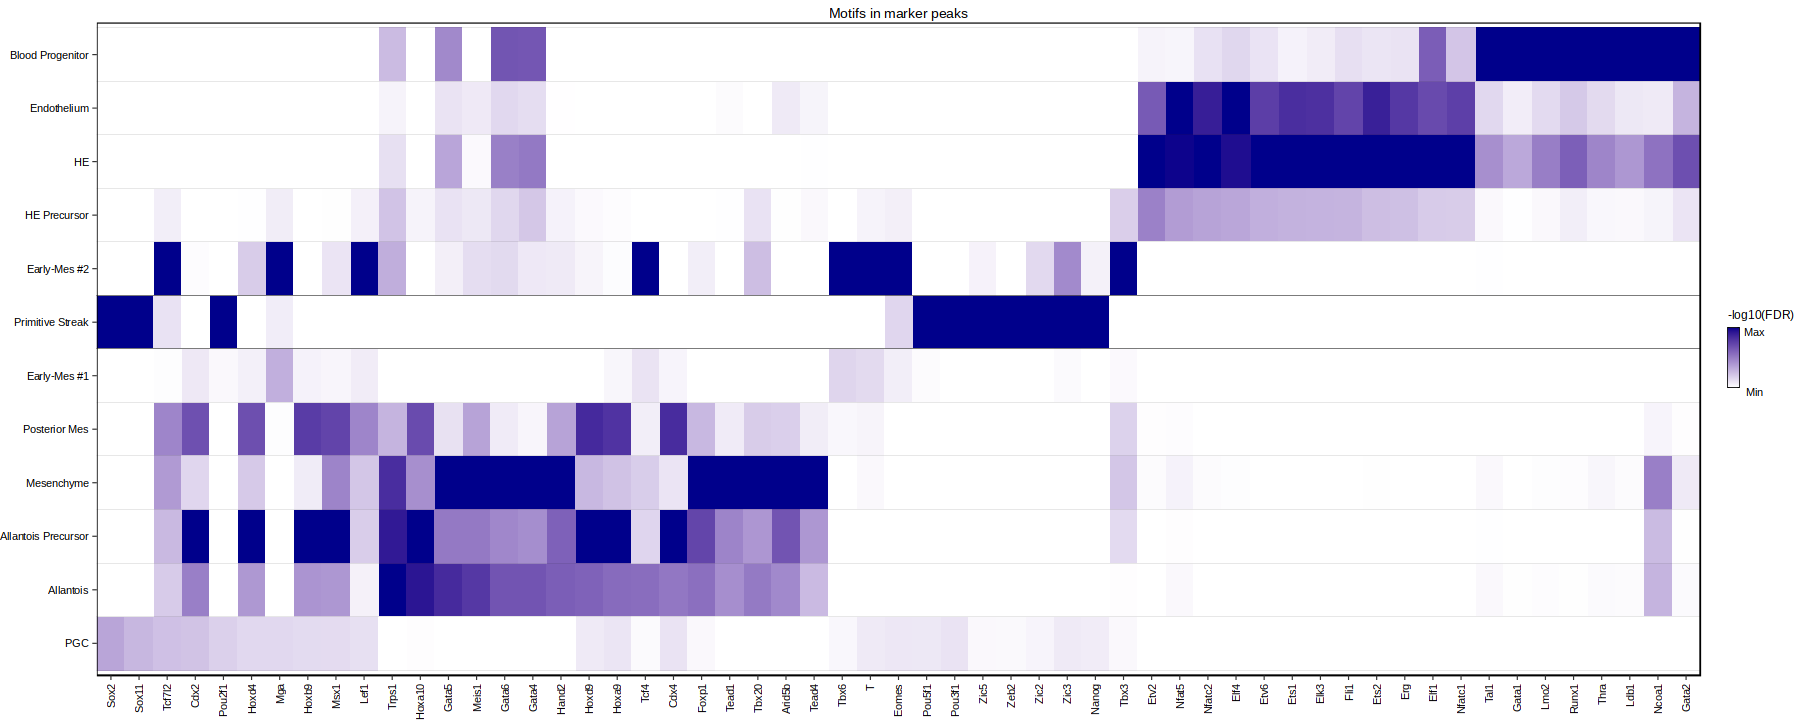

In [20]:
options(repr.plot.width=15, repr.plot.height=6)
plot_enr_heatmap(enrichMotifs, ntop = 10)

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-6269317f2891-Date-2024-11-25_Time-14-24-32.log
If there is an issue, please report to github with logFile!



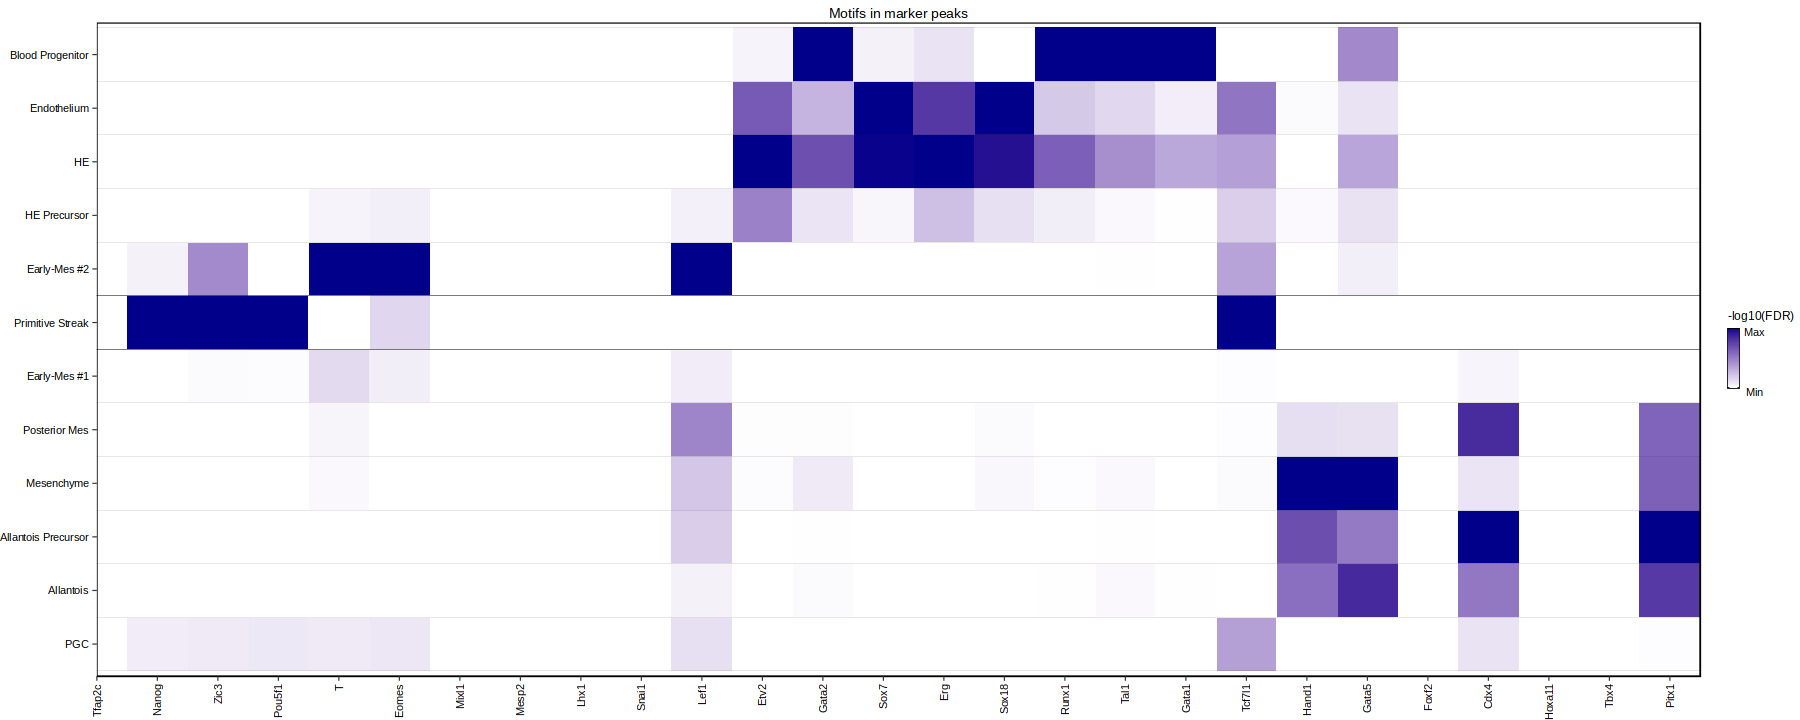

In [34]:
p3 = plot_enr_heatmap(enrichMotifs, TFs = str_to_title(TFs_plot), ntop=10000)
p3

In [35]:
args$outdir

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/revisions/05_SCENICplus/"

In [36]:
ggsave(file.path(args$outdir, 'WT_celltype_motif_enrichment_SCENICplus.pdf'), 
       plot = p3 + theme(legend.position = 'none'),
       width = 80, 
       height = 40, 
       units = "mm")